In [ ]:
# TODO:

# implement YaRN for positinal encodings

# MHA: num_query_heads == num_kv_heads
# GQA: 1 < num_kv_heads < num_query_heads and num_query_heads % num_kv_heads == 0
# MQA: num_kv_heads == 1

In [ ]:
import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
from typing import Optional
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum


import training_engine  
import inference_engine 
from utils import RMSNorm


MODEL_CONFIGS_GQA = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "vocab_size"  : 2**11,  # 2048
   
    "num_layers": 2,

    "num_attn_heads": 2**2, # 4
    "num_kv_heads"  : 2,  

   
    "batch_size"  : 2**4,   # 16
    "learning_rate" : 1e-3,

    "save_path" : "../models/level4.1_grouped_query_attn.pt",
    "loss_history" : "../models/level4.1_grouped_query_attn_loss_history.txt",

}



# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)




cuda


In [2]:
class GroupedQueryCausalAttention(nn.Module):
    """
    Grouped Query Attention (GQA) with causal masking + KV-cache support.
    """
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        num_kv_heads: int,
        max_seq_len: int,
    ):
        super().__init__()
        assert embed_dim % num_heads == 0
        assert num_heads % num_kv_heads == 0

        self.embed_dim    = embed_dim
        self.num_heads    = num_heads
        self.num_kv_heads = num_kv_heads
        self.n_rep        = num_heads // num_kv_heads
        self.head_dim     = embed_dim // num_heads
        self.max_seq_len  = max_seq_len

        self.q_proj = nn.Parameter(torch.randn(embed_dim, num_heads * self.head_dim) * 0.02)
        self.k_proj = nn.Parameter(torch.randn(embed_dim, num_kv_heads * self.head_dim) * 0.02)
        self.v_proj = nn.Parameter(torch.randn(embed_dim, num_kv_heads * self.head_dim) * 0.02)
        self.o_proj = nn.Parameter(torch.randn(embed_dim, embed_dim) * 0.02)

    def forward(
        self,
        x: torch.Tensor,                     # (batch, seq, d)
        kv_cache: Optional["KVCache"] = None,
        layer_idx: int = 0,
        start_pos: int = 0,
    ) -> torch.Tensor:
        b, s, _ = x.shape

        # Projections
        q = einsum(x, self.q_proj, "b s d, d d_out -> b s d_out")
        k = einsum(x, self.k_proj, "b s d, d d_out -> b s d_out")
        v = einsum(x, self.v_proj, "b s d, d d_out -> b s d_out")

        # Split heads
        q = rearrange(q, "b s (h d) -> b h s d", h=self.num_heads)
        k = rearrange(k, "b s (h d) -> b h s d", h=self.num_kv_heads)
        v = rearrange(v, "b s (h d) -> b h s d", h=self.num_kv_heads)

        # ----- KV Cache handling -----
        if kv_cache is not None:
            k, v = kv_cache.update(layer_idx, k, v)          # full cached K/V

        # Repeat KV heads for GQA
        k = repeat(k, "b h s d -> b (h rep) s d", rep=self.n_rep)
        v = repeat(v, "b h s d -> b (h rep) s d", rep=self.n_rep)

        # Attention scores
        scale = self.head_dim ** -0.5
        attn = einsum(q, k, "b h q d, b h k d -> b h q k") * scale

        # Causal mask (only needed when we have more than 1 token)
        if s > 1 or start_pos == 0:
            # Build mask that accounts for already-cached tokens
            total_len = k.shape[-2]
            mask = torch.ones(s, total_len, device=x.device, dtype=torch.bool)
            mask = torch.triu(mask, diagonal=1 + start_pos)
            attn = attn.masked_fill(mask, float("-inf"))

        attn = torch.softmax(attn, dim=-1)

        out = einsum(attn, v, "b h q k, b h k d -> b h q d")
        out = rearrange(out, "b h s d -> b s (h d)")

        return einsum(out, self.o_proj, "b s d, d d_out -> b s d_out")

In [3]:
class TransformerLayer(nn.Module):
    """
    One transformer block.
    Currently contains only attention (you can later add FFN / SwiGLU / MoE here).
    """
    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        num_kv_heads: int,
        max_seq_len: int,
        layer_idx: int,
    ):
        super().__init__()
        self.layer_idx = layer_idx
        self.rms_norm = RMSNorm(embed_dim)

        self.attn = GroupedQueryCausalAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_kv_heads=num_kv_heads,
            max_seq_len=max_seq_len,
        )

        # Future expansion point:
        # self.ffn = SwiGLU(...) or MoE(...)

    def forward(
        self,
        x: torch.Tensor,
        kv_cache: Optional["KVCache"] = None,
        start_pos: int = 0,
    ) -> torch.Tensor:
        # Pre-norm + attention + residual
        x = x + self.attn(
            self.rms_norm(x),
            kv_cache=kv_cache,
            layer_idx=self.layer_idx,
            start_pos=start_pos,
        )
        # Future: x = x + self.ffn(self.rms_norm_2(x))
        return x

In [4]:
class Level5GQAModel(nn.Module):
    """
    Hierarchical GQA model with fixed sinusoidal positional encoding.
    Compatible with the advanced_inference engine (prefill / decode + KVCache).
    """
    def __init__(self, config: dict=MODEL_CONFIGS_GQA):
        super().__init__()
        self.embed_dim    = config["embed_dim"]
        self.vocab_size   = config["vocab_size"]
        self.max_seq_len  = config["max_seq_len"]
        self.num_layers   = config["num_layers"]
        self.num_heads    = config["num_attn_heads"]
        self.num_kv_heads = config["num_kv_heads"]

        # Embeddings
        self.embed   = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)

        # Fixed sinusoidal positional encodings
        pos_enc = self._build_sinusoidal_pe(self.max_seq_len, self.embed_dim)
        self.register_buffer("pos_enc", pos_enc)

        # Transformer layers
        self.layers = nn.ModuleList([
            TransformerLayer(
                embed_dim=self.embed_dim,
                num_heads=self.num_heads,
                num_kv_heads=self.num_kv_heads,
                max_seq_len=self.max_seq_len,
                layer_idx=i,
            )
            for i in range(self.num_layers)
        ])

        self.final_norm = RMSNorm(self.embed_dim)

    @staticmethod
    def _build_sinusoidal_pe(max_seq_len: int, embed_dim: int) -> torch.Tensor:
        position = torch.arange(max_seq_len, dtype=torch.float)
        inv_freq = torch.exp(
            torch.arange(0, embed_dim, 2, dtype=torch.float)
            * (-math.log(10000.0) / embed_dim)
        )
        angles = einsum(position, inv_freq, "pos, half -> pos half")

        pe = torch.zeros(max_seq_len, embed_dim)
        pe[:, 0::2] = torch.sin(angles)
        pe[:, 1::2] = torch.cos(angles)
        return pe

    def forward(self, idx, kv_cache=None, start_pos=0):
        b, s = idx.shape

        if start_pos + s > self.max_seq_len:
            raise ValueError(
                f"start_pos ({start_pos}) + s ({s}) = {start_pos + s} "
                f"> max_seq_len ({self.max_seq_len}). "
                "Inference engine should have truncated the cache."
            )

        x = self.embed[idx] + self.pos_enc[start_pos : start_pos + s]
        # Transformer layers
        for layer in self.layers:
            x = layer(x, kv_cache=kv_cache, start_pos=start_pos)

        # Final norm + unembed
        x = self.final_norm(x)
        logits = einsum(x, self.unembed, "b s d, d v -> b s v")
        return logits

Step 0000 | Batch Loss: 7.6266 nats
Step 0005 | Batch Loss: 7.5865 nats
Step 0010 | Batch Loss: 7.5433 nats
Step 0015 | Batch Loss: 7.4717 nats
Step 0020 | Batch Loss: 7.4222 nats
Step 0025 | Batch Loss: 7.3826 nats
Step 0030 | Batch Loss: 7.3014 nats
Step 0035 | Batch Loss: 7.2612 nats
Step 0040 | Batch Loss: 7.1933 nats
Step 0045 | Batch Loss: 7.2003 nats
Step 0050 | Batch Loss: 7.1901 nats
Step 0055 | Batch Loss: 7.1722 nats
Step 0060 | Batch Loss: 7.1031 nats
Step 0065 | Batch Loss: 7.1012 nats
Step 0070 | Batch Loss: 7.1178 nats
Step 0075 | Batch Loss: 7.0714 nats
Step 0080 | Batch Loss: 7.1018 nats
Step 0085 | Batch Loss: 7.0486 nats
Step 0090 | Batch Loss: 7.0645 nats
Step 0095 | Batch Loss: 7.0868 nats
Step 0099 | Batch Loss: 7.0563 nats

Saving model weights to: ../models/level4.1_grouped_query_attn.pt
Loss history successfully saved to ../models/level4.1_grouped_query_attn_loss_history.txt
Loaded 100 steps from ../models/level4.1_grouped_query_attn_loss_history.txt


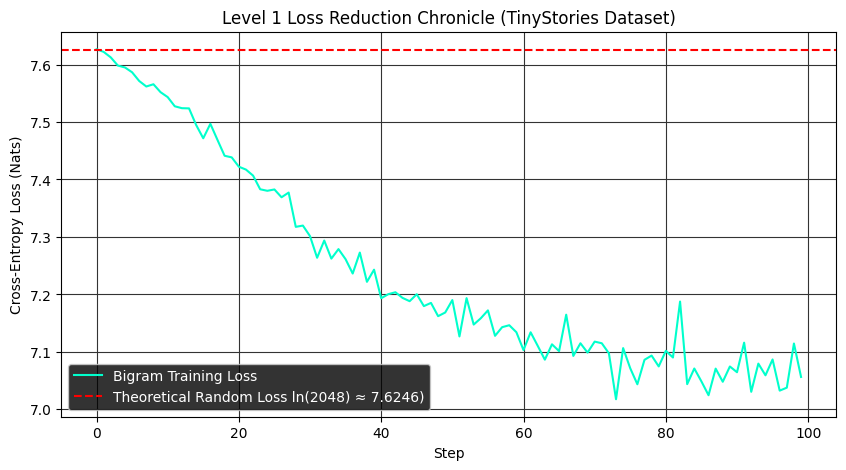

In [5]:
configs = MODEL_CONFIGS_GQA
model = Level5GQAModel()

training_engine.train_and_save_model(model, configs, device, 100)
training_engine.plot_loss_history(configs)


In [6]:
training_engine.inspect_weight_file(configs["save_path"], False)

Loaded state_dict from ..\models\level4.1_grouped_query_attn.pt
Number of parameter tensors: 14
Number of parameters: 139,360

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, requires_grad=False, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, requires_grad=False, numel=65,536
pos_enc: shape=(64, 32), dtype=torch.float32, requires_grad=False, numel=2,048
layers.0.rms_norm.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
layers.0.attn.q_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.0.attn.k_proj: shape=(32, 16), dtype=torch.float32, requires_grad=False, numel=512
layers.0.attn.v_proj: shape=(32, 16), dtype=torch.float32, requires_grad=False, numel=512
layers.0.attn.o_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.1.rms_norm.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
layers.1.attn.q_proj: shape=(32, 32), dtype=torch.float32, requires_gr

In [7]:
prompt = "write a story about"
model_scaffold = Level5GQAModel()

samples = inference_engine.simple_inference(model_scaffold, MODEL_CONFIGS_GQA, 200, prompt, device, temperature=0.5)
print(samples)


[INFO] Starting inference with prompt: write a story about
[INFO] Loaded weights from ../models/level4.1_grouped_query_attn.pt  (137,312 parameters)
full_seq before 1/200:
[1430, 787, 138, 379, 68, 264, 52, 395]
context_window_limited_seq_tensor.shape-> 
torch.Size([1, 8])
[INFO] Step 1/200: Context window length: 8
model_output_logits.shape->
torch.Size([1, 8, 2048])
last_token_logits.shape->
torch.Size([2048])
probabilities.shape-> 
torch.Size([2048])
probabilities-> 
tensor([1.8016e-02, 3.0871e-03, 3.2267e-05,  ..., 2.0958e-05, 1.6680e-05,
        1.7890e-05], device='cuda:0')
next_token_tensor.shape= 
next_token_tensor.shape-> 
torch.Size([1])
next_token_tensor-> 
tensor([322], device='cuda:0')
full_seq.append after append: 
[1430, 787, 138, 379, 68, 264, 52, 395, 322]
--------------------------------------------------------------------------------
full_seq before 2/200:
[1430, 787, 138, 379, 68, 264, 52, 395, 322]
context_window_limited_seq_tensor.shape-> 
torch.Size([1, 9])
[INFO

In [8]:
prompt = "write a story about"
model_scaffold = Level5GQAModel()

samples = inference_engine.advanced_inference(model_scaffold, MODEL_CONFIGS_GQA, 200, prompt, device, temperature=0.5)
print(samples)


[INFO] Loaded weights from ../models/level4.1_grouped_query_attn.pt  (137,312 parameters)


ValueError: start_pos (64) + s (1) = 65 > max_seq_len (64). Inference engine should have truncated the cache.